In [106]:
%load_ext autoreload
%autoreload 2
import pickle
import glob
import sys, copy
import numpy as np
import pyccl as ccl
sys.path.append('../validation_capish_comparison_to_standard_approach/')
import ModelClusterObservables
sys.path.append('../modules/')
import halo._halo_abundance
from astropy.table import Table
import halo.halo_catalogue
import matplotlib.pyplot as plt
def load(filename, **kwargs):
    with open(filename, 'rb') as fin:
        return pickle.load(fin, **kwargs)
import itertools
params = {
    "font.family": "serif",
    "font.serif": ["Times", "Times New Roman", "DejaVu Serif"],
    "axes.labelsize": 10,
    "font.size": 10,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "text.usetex": True,
    "figure.figsize": [3.386, 3.386],
    "figure.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
}
plt.rcParams.update(params)
import configparser

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [133]:
log10m_edges = np.linspace(13.5, 16, 20)
log10m_center = (log10m_edges[:-1] + log10m_edges[1:]) / 2
z_edges = np.linspace(0.2, 1.2, 5)
def binning(edges): return [[edges[i],edges[i+1]] for i in range(len(edges)-1)]
Redshift_bin = binning(z_edges)
Logm_bin = binning(log10m_edges)
def N_pred(hmf):
    default_config = configparser.ConfigParser()
    default_config.read('../config/capish_internal_validation.ini')
    default_config['halo_catalogue']['hmf_name'] = hmf
    ClusterAbundanceObject = ModelClusterObservables.UniversePrediction( default_config=default_config )
    CCLCosmologyObject = ClusterAbundanceObject.params_default['CCL_cosmology']
    hmf = halo.halo_catalogue.get_massfunc_from_config(default_config['halo_catalogue'])
    bias = halo.halo_catalogue.get_bias_from_config(default_config['halo_catalogue'])
    sky_area = float( default_config['halo_catalogue']['sky_area'] )
    fsky = sky_area/(4*np.pi) 
    logm_grid = np.linspace( float( default_config['halo_catalogue']['log10m_min']),
                            float( default_config['halo_catalogue']['log10m_max']),
                            int( default_config['halo_catalogue']['n_mass_bins'] ) )
    z_grid = np.linspace( float( default_config['halo_catalogue']['z_min'] ),
                            float( default_config['halo_catalogue']['z_max'] ),
                            int( default_config['halo_catalogue']['n_redshift_bins'] ) )
    
    HaloAbundance = halo._halo_abundance.HaloAbundance(CCLCosmologyObject = CCLCosmologyObject,
                                                       CCLHmf = hmf, 
                                                       CCLBias = bias,
                                                       sky_area =sky_area)
    
    HaloAbundance.compute_multiplicity_grid_MZ(z_grid = z_grid, log10m_grid = logm_grid)
    HaloAbundance.compute_halo_bias_grid_MZ(z_grid = z_grid, log10m_grid = logm_grid)
    N = HaloAbundance.Cluster_Abundance_MZ(Redshift_bin = Redshift_bin , Proxy_bin = Logm_bin, method = 'simps')
    Nb = HaloAbundance.Nhalo_bias_MZ(Redshift_bin = Redshift_bin , Proxy_bin = Logm_bin, method = 'simps')
    
    return N

In [134]:
halo_cat_flagship = Table.read('../../capish_data/flagship.fits')
z = halo_cat_flagship['true_redshift_gal']
m200bh, m200ch, m500ch = halo_cat_flagship['m200b'], halo_cat_flagship['m200c'],halo_cat_flagship['m500c']
m200b, m200c, m500c = m200bh / 0.67, m200ch / 0.67, m500ch / 0.67

In [135]:
H, _, _ = np.histogram2d(
    np.log10(m200b), z,
    bins=[log10m_edges, z_edges]
)

In [136]:
H.shape

(19, 4)

In [137]:
N_TK10 = N_pred('Tinker10')
N_TK08 = N_pred('Tinker08')

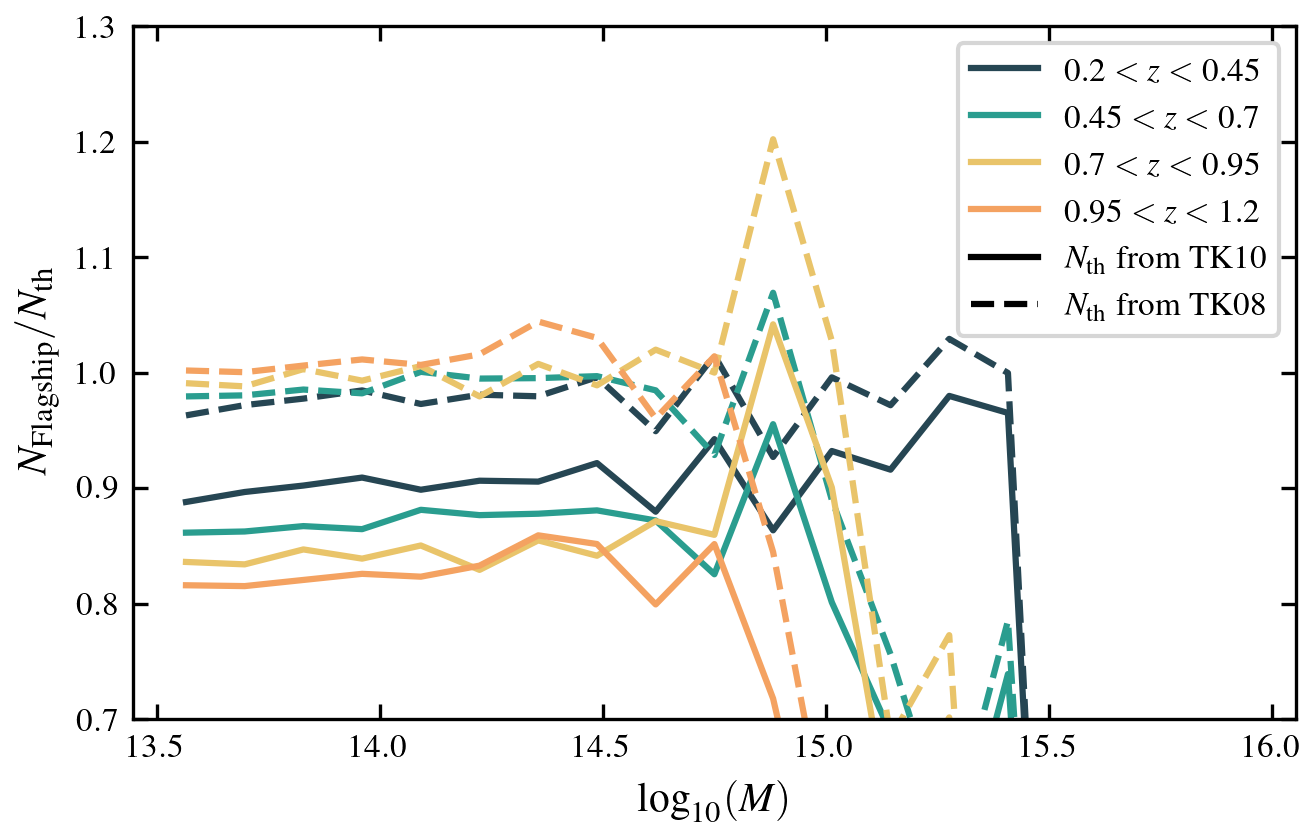

In [143]:
plt.figure(figsize=(5,3))
color = ["#264653", "#2A9D8F", "#E9C46A", "#F4A261", "#E76F51"]
for i in range(len(Redshift_bin)):
    plt.plot(np.mean(Logm_bin, axis=1), H.T[i,:]/N_TK10[i,:], color = color[i],  label = str(Redshift_bin[i][0]) + r' $< z <$ ' + str(Redshift_bin[i][1]))
    plt.plot(np.mean(Logm_bin, axis=1), H.T[i,:]/N_TK08[i,:], '--',  color = color[i])
  #  plt.plot(H.T[i,:])
#plt.vlines(13.3, 0, 10.5)
#plt.ylim(1e-4, 10)
plt.plot([], [], '-k', label = r'$N_{\rm th}$ from TK10')
plt.plot([], [], '--k', label = r'$N_{\rm th}$ from TK08')
plt.ylabel(r'$N_{\rm Flagship}/N_{\rm th}$')
plt.xlabel(r'$\log_{10}(M)$')
plt.legend()
plt.ylim(0.7, 1.3)
#plt.yscale('log')
plt.savefig(f'halo_count_bias_flagship.png', dpi = 300, bbox_inches='tight',)